# 11 — Prediction Performance

## Goal

Summarize prediction performance from the three existing modelling experiments:

1. **Stock-specific models** — Notebook 08
2. **Pooled global models** — Notebook 09
3. **Cross-stock / leave-one-stock-out models** — Notebook 10

This notebook does **not retrain models**.

Main metrics:
- Balanced Accuracy
- Macro F1
- Multiclass ROC-AUC (OvR)
- Confusion Matrix

The 2025 predictions produced by the earlier notebooks are reused here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load prediction files

Change only these three paths if your Kaggle file locations are different.

In [2]:
BASELINE_PATH = "/kaggle/input/notebooks/phyothaw/08-baseline-modelling-ipynb/baseline_predictions.csv"
POOLED_PATH   = "/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/pooled_model_predictions.csv"
LOSO_PATH     = "/kaggle/input/notebooks/phyothaw/10-cross-stock-generalisation-ipynb/loso_model_predictions.csv"

baseline = pd.read_csv(BASELINE_PATH)
pooled   = pd.read_csv(POOLED_PATH)
loso     = pd.read_csv(LOSO_PATH)

print("Stock-specific rows:", len(baseline))
print("Pooled rows:", len(pooled))
print("Cross-stock rows:", len(loso))

Stock-specific rows: 5650
Pooled rows: 5650
Cross-stock rows: 4520


## 3. Prepare the three scenarios

The files use slightly different stock-column names, so we standardize them to `ticker`.

In [3]:
# Standardize stock column
if "held_out_stock" in loso.columns:
    loso = loso.rename(columns={"held_out_stock": "ticker"})

# Standardize Dummy model name
for df in [baseline, pooled, loso]:
    df["model"] = df["model"].replace({
        "Dummy": "Dummy Classifier"
    })

baseline["scenario"] = "Stock-specific"
pooled["scenario"]   = "Pooled"
loso["scenario"]     = "Cross-stock"

predictions = pd.concat(
    [baseline, pooled, loso],
    ignore_index=True
)

predictions["date"] = pd.to_datetime(predictions["date"])

print("Scenarios:", predictions["scenario"].unique())
print("Models:", predictions["model"].unique())
display(predictions.head())

Scenarios: ['Stock-specific' 'Pooled' 'Cross-stock']
Models: ['Dummy Classifier' 'Random Forest' 'XGBoost' 'Logistic Regression' 'LSTM']


,ticker,date,model,actual,predicted,prob_down,prob_neutral,prob_up,scenario
0,BRK-B,2025-01-02,Dummy Classifier,0,1,0.0000,1.0000,0.0000,Stock-specific
1,BRK-B,2025-01-03,Dummy Classifier,0,1,0.0000,1.0000,0.0000,Stock-specific
2,BRK-B,2025-01-06,Dummy Classifier,1,1,0.0000,1.0000,0.0000,Stock-specific
3,BRK-B,2025-01-07,Dummy Classifier,1,1,0.0000,1.0000,0.0000,Stock-specific
4,BRK-B,2025-01-08,Dummy Classifier,2,1,0.0000,1.0000,0.0000,Stock-specific


## 4. Simple validation

Before calculating metrics, check that:
- probabilities are present,
- probabilities sum to approximately 1,
- target classes are 0, 1, 2.

In [4]:
PROB_COLS = ["prob_down", "prob_neutral", "prob_up"]

print("Missing probability values:",
      predictions[PROB_COLS].isna().sum().sum())

prob_sum = predictions[PROB_COLS].sum(axis=1)

print("Probabilities sum to 1:",
      np.allclose(prob_sum, 1.0, atol=1e-5))

print("Actual classes:",
      sorted(predictions["actual"].unique()))

Missing probability values: 0
Probabilities sum to 1: True
Actual classes: [np.int64(0), np.int64(1), np.int64(2)]


## 5. Metric function

For each model we calculate the same three metrics.

**Higher is better** for all three metrics.

In [5]:
def calculate_metrics(group):
    y_true = group["actual"]
    y_pred = group["predicted"]
    y_prob = group[PROB_COLS]

    try:
        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            labels=[0, 1, 2]
        )
    except ValueError:
        auc = np.nan

    return pd.Series({
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "roc_auc_ovr": auc
    })

## 6. Overall performance by scenario and model

This is the main comparison table.

In [6]:
performance_summary = (
    predictions
    .groupby(["scenario", "model"])
    .apply(calculate_metrics, include_groups=False)
    .reset_index()
)

performance_summary = performance_summary.sort_values(
    ["scenario", "balanced_accuracy"],
    ascending=[True, False]
)

display(performance_summary)

,scenario,model,balanced_accuracy,macro_f1,roc_auc_ovr
1,Cross-stock,Logistic Regression,0.3957,0.3993,0.5554
3,Cross-stock,XGBoost,0.3562,0.3289,0.5118
2,Cross-stock,Random Forest,0.3376,0.3102,0.4993
0,Cross-stock,Dummy Classifier,0.3333,0.1819,0.5000
6,Pooled,Logistic Regression,0.3899,0.3818,0.5902
7,Pooled,Random Forest,0.3707,0.3543,0.5664
8,Pooled,XGBoost,0.3526,0.3379,0.5307
5,Pooled,LSTM,0.3463,0.2820,0.5635
4,Pooled,Dummy Classifier,0.3333,0.1819,0.5000
13,Stock-specific,XGBoost,0.3830,0.3419,0.5518


## 7. Best model in each scenario

This answers a simple question:

**Which model achieved the highest Balanced Accuracy in each evaluation scenario?**

In [7]:
best_models = (
    performance_summary.loc[
        performance_summary
        .groupby("scenario")["balanced_accuracy"]
        .idxmax()
    ]
    .sort_values("scenario")
    .reset_index(drop=True)
)

display(best_models)

,scenario,model,balanced_accuracy,macro_f1,roc_auc_ovr
0,Cross-stock,Logistic Regression,0.3957,0.3993,0.5554
1,Pooled,Logistic Regression,0.3899,0.3818,0.5902
2,Stock-specific,XGBoost,0.3830,0.3419,0.5518


## 8. Performance by stock

This table helps show whether performance differs across BRK-B, CVX, GE, MSFT, and NVDA.

In [8]:
performance_by_stock = (
    predictions
    .groupby(["scenario", "ticker", "model"])
    .apply(calculate_metrics, include_groups=False)
    .reset_index()
)

display(
    performance_by_stock.sort_values(
        ["scenario", "ticker", "balanced_accuracy"],
        ascending=[True, True, False]
    )
)

,scenario,ticker,model,balanced_accuracy,macro_f1,roc_auc_ovr
1,Cross-stock,BRK-B,Logistic Regression,0.3570,0.2940,0.5403
0,Cross-stock,BRK-B,Dummy Classifier,0.3333,0.1453,0.5000
2,Cross-stock,BRK-B,Random Forest,0.3333,0.1205,0.5500
3,Cross-stock,BRK-B,XGBoost,0.3333,0.1188,0.5338
7,Cross-stock,CVX,XGBoost,0.3760,0.2857,0.5257
...,...,...,...,...,...,...
69,Stock-specific,NVDA,XGBoost,0.3415,0.3235,0.5691
68,Stock-specific,NVDA,Random Forest,0.3414,0.3021,0.5819
65,Stock-specific,NVDA,Dummy Classifier,0.3333,0.2087,0.5000
67,Stock-specific,NVDA,Logistic Regression,0.2833,0.2319,0.4727


## 9. Simple Balanced Accuracy chart

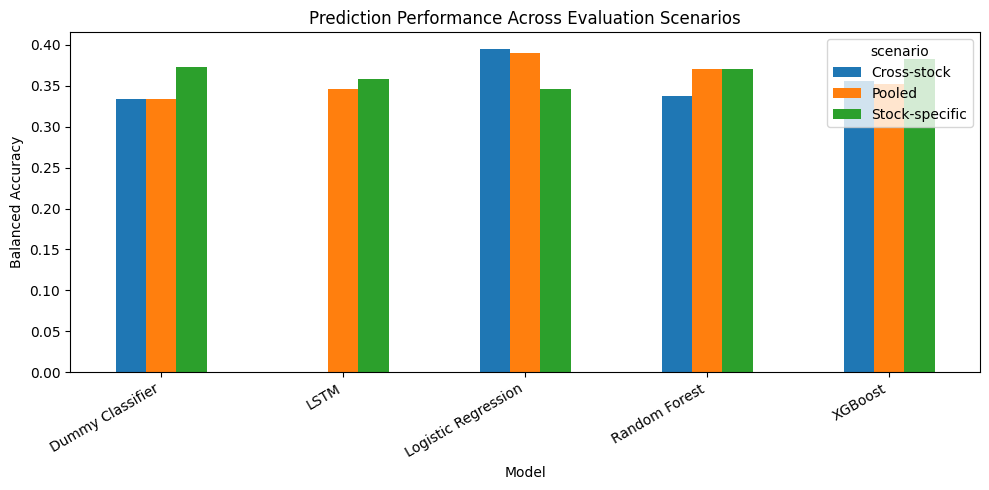

In [9]:
chart_df = performance_summary.pivot(
    index="model",
    columns="scenario",
    values="balanced_accuracy"
)

chart_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Balanced Accuracy")
plt.xlabel("Model")
plt.title("Prediction Performance Across Evaluation Scenarios")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 10. Confusion matrices for the best model in each scenario

To keep the notebook simple, we show one confusion matrix per scenario rather than one for every model.

Classes:
- 0 = Down
- 1 = Neutral
- 2 = Up

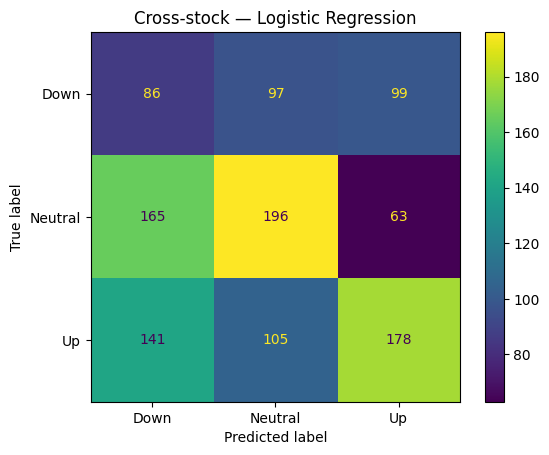

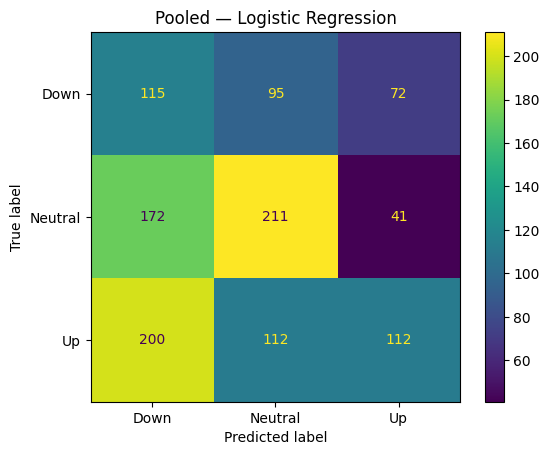

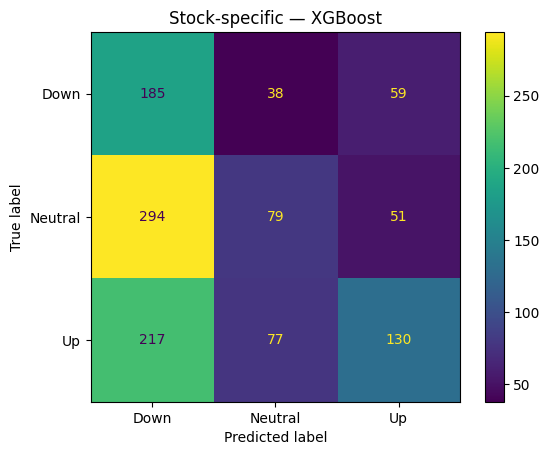

In [10]:
for _, row in best_models.iterrows():

    scenario = row["scenario"]
    model = row["model"]

    subset = predictions[
        (predictions["scenario"] == scenario) &
        (predictions["model"] == model)
    ]

    ConfusionMatrixDisplay.from_predictions(
        subset["actual"],
        subset["predicted"],
        labels=[0, 1, 2],
        display_labels=["Down", "Neutral", "Up"]
    )

    plt.title(f"{scenario} — {model}")
    plt.show()